In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_excel(
    "glass.xlsx",
    sheet_name="glass"
)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (214, 10)

First 5 Rows:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  

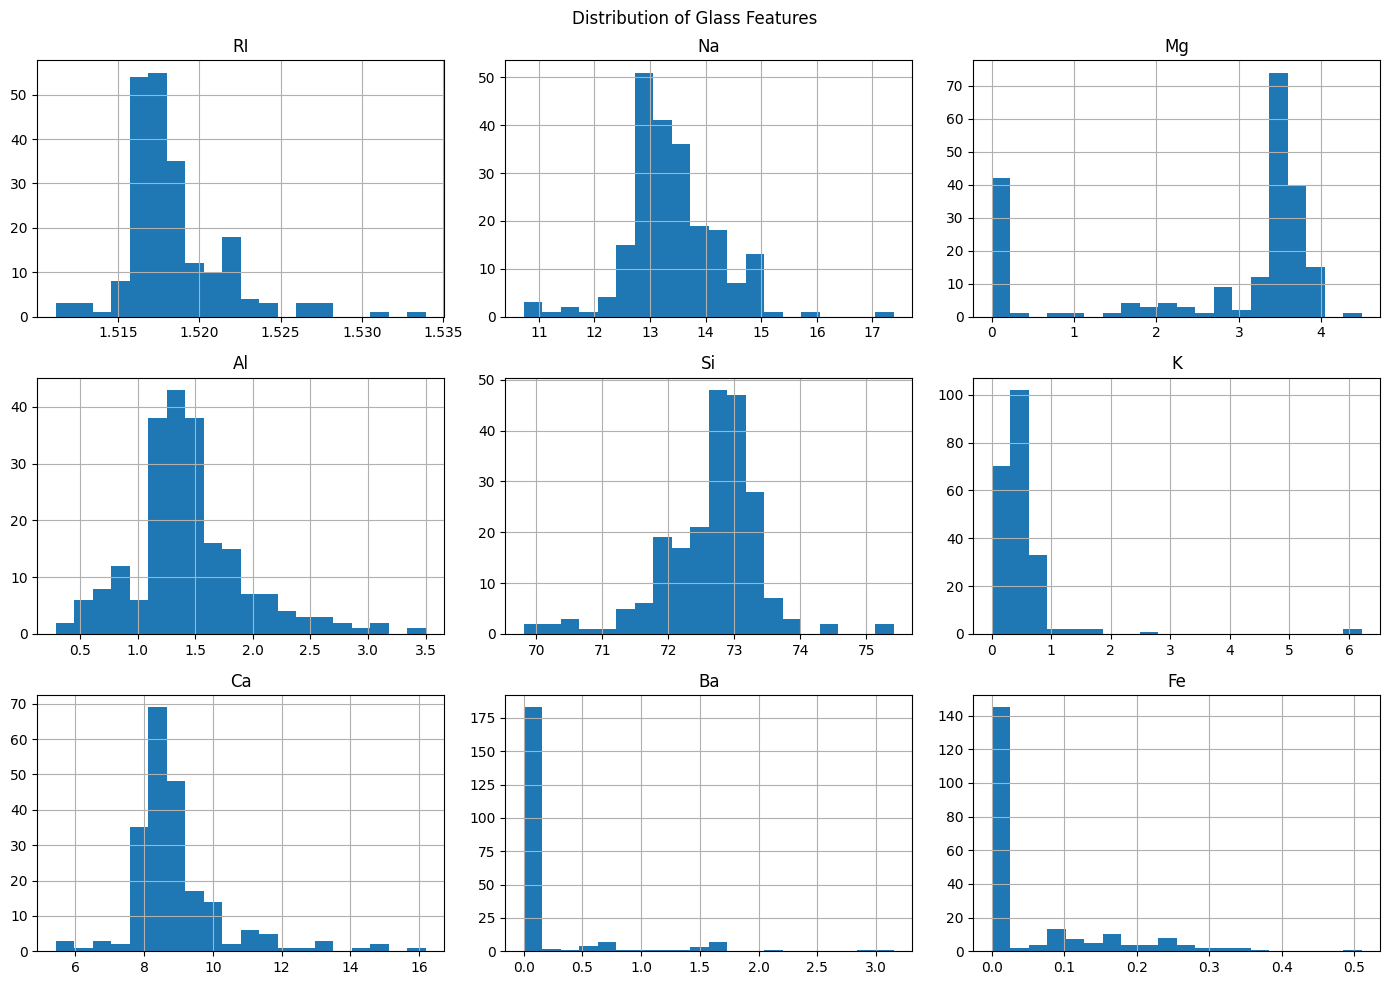

In [3]:
features = [
    'RI',
    'Na',
    'Mg',
    'Al',
    'Si',
    'K',
    'Ca',
    'Ba',
    'Fe'
]

df[features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Glass Features")
plt.tight_layout()
plt.show()

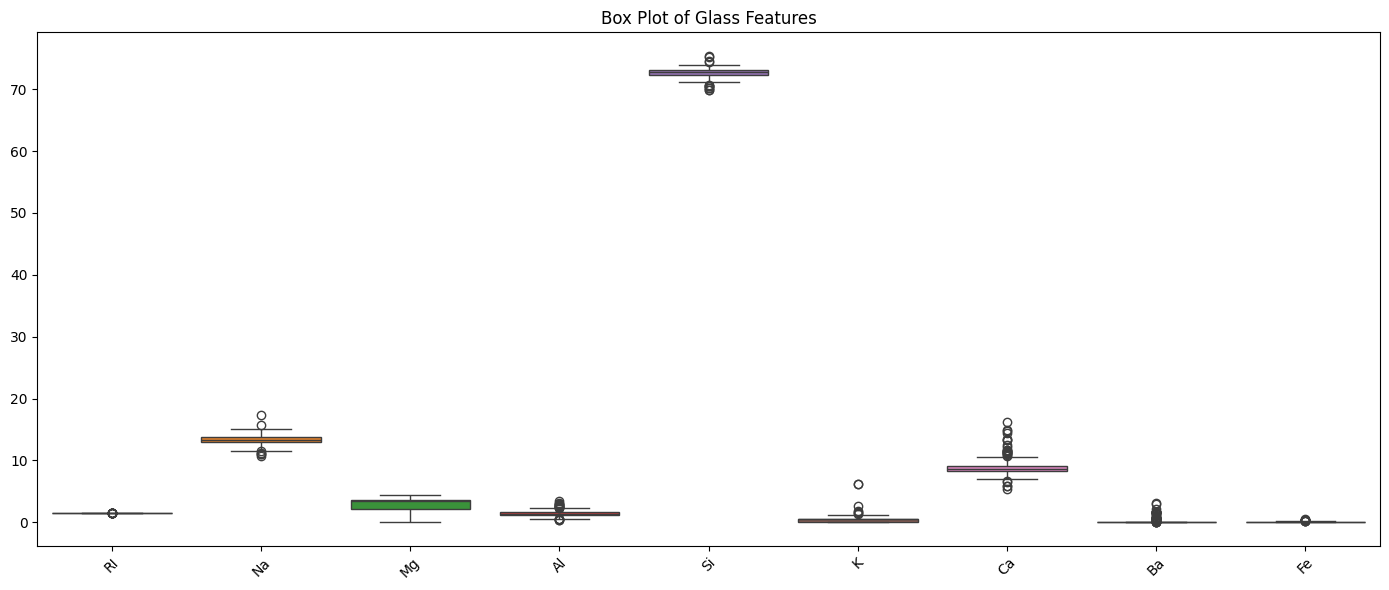

In [4]:
#box plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df[features]
)

plt.title("Box Plot of Glass Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

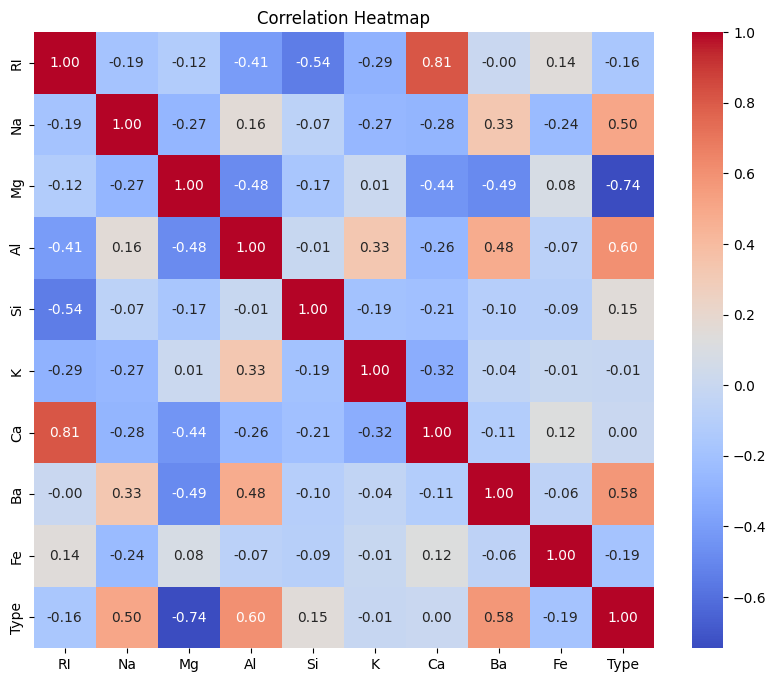

In [5]:
#Correlation
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [7]:
#Task-3
print("Total Missing Values:")
print(df.isnull().sum().sum())

print("\nData Types:")
print(df.dtypes)

print("\nGlass Type Distribution:")
print(df['Type'].value_counts())

X = df.drop(
    columns=['Type']
)

y = df['Type']

Total Missing Values:
0

Data Types:
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

Glass Type Distribution:
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [8]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (171, 9)
Testing Shape: (43, 9)


In [9]:
#Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


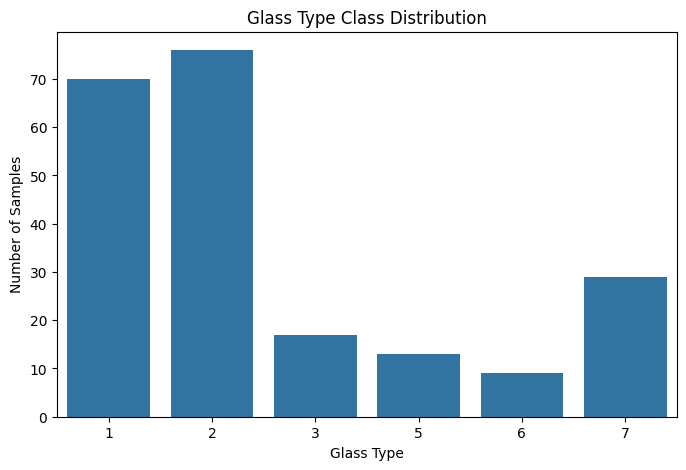

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [10]:
#Handling imblanced data
plt.figure(figsize=(8, 5))

sns.countplot(
    x=y
)

plt.title("Glass Type Class Distribution")
plt.xlabel("Glass Type")
plt.ylabel("Number of Samples")

plt.show()

print(y.value_counts())

In [11]:
# Task 4: Random Forest Model Implementation
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_pred = rf_model.predict(
    X_test_scaled
)

print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.81        43
   macro avg       0.87      0.85      0.84        43
weighted avg       0.83      0.81      0.81        43



In [12]:
#Metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.813953488372093
Precision: 0.8283499446290145
Recall   : 0.813953488372093
F1 Score : 0.8147408325435591


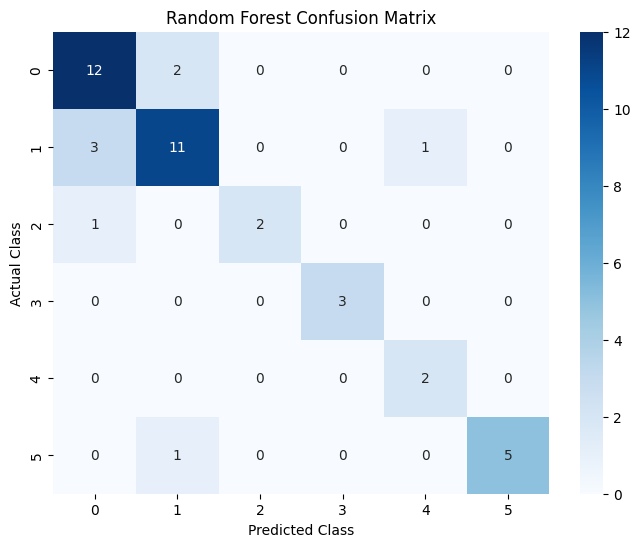

In [13]:
#Random Forest Results Visualization
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

Feature Importance:
Mg    0.177898
Ca    0.141359
Na    0.131755
Al    0.123919
K     0.122480
RI    0.112217
Si    0.087921
Ba    0.082364
Fe    0.020088
dtype: float64


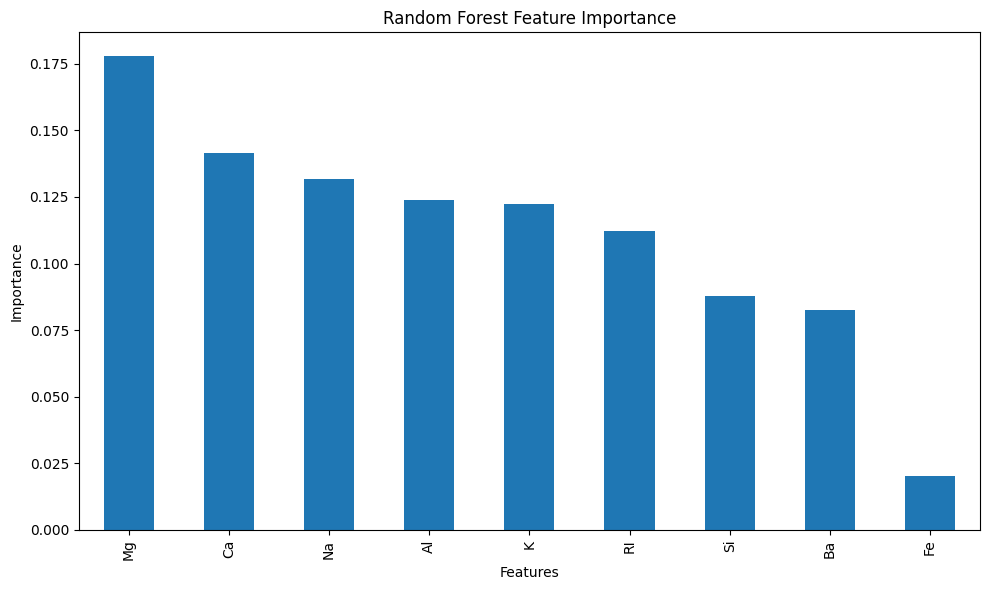

In [15]:
#Feature Importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

print("Feature Importance:")
print(importance)

#visualize
plt.figure(figsize=(10, 6))

importance.plot(
    kind='bar'
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [17]:
#task-5
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(
    X_train_scaled,
    y_train
)

bagging_pred = bagging_model.predict(
    X_test_scaled
)

#Bosting
boosting_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting_model.fit(
    X_train_scaled,
    y_train
)

boosting_pred = boosting_model.predict(
    X_test_scaled
)

In [19]:
#comprasion
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Bagging',
        'Boosting'
    ],

    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, bagging_pred),
        accuracy_score(y_test, boosting_pred)
    ],

    'Precision': [
        precision_score(
            y_test,
            rf_pred,
            average='weighted'
        ),
        precision_score(
            y_test,
            bagging_pred,
            average='weighted'
        ),
        precision_score(
            y_test,
            boosting_pred,
            average='weighted'
        )
    ],

    'Recall': [
        recall_score(
            y_test,
            rf_pred,
            average='weighted'
        ),
        recall_score(
            y_test,
            bagging_pred,
            average='weighted'
        ),
        recall_score(
            y_test,
            boosting_pred,
            average='weighted'
        )
    ],

    'F1 Score': [
        f1_score(
            y_test,
            rf_pred,
            average='weighted'
        ),
        f1_score(
            y_test,
            bagging_pred,
            average='weighted'
        ),
        f1_score(
            y_test,
            boosting_pred,
            average='weighted'
        )
    ]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.813953   0.828350  0.813953  0.814741
1        Bagging  0.813953   0.822523  0.813953  0.811869
2       Boosting  0.395349   0.466667  0.395349  0.363817


# **Final Conclusion**



The Glass dataset was analyzed using Exploratory Data Analysis techniques
including statistical summaries, histograms, box plots, and correlation
analysis.

The dataset contained nine numerical chemical features and a target variable
representing different glass types. No missing values were found, and there
were no categorical predictor variables requiring encoding.

The dataset was divided into training and testing sets using an 80:20 split.
Standardization was applied to the numerical features as part of the
preprocessing process.

A Random Forest classifier was implemented using multiple Decision Trees.
Class weights were used to help address potential class imbalance.

The Random Forest model was evaluated using accuracy, precision, recall, and
F1-score. A confusion matrix was used to visualize the classification results,
and feature importance was analyzed to determine which chemical properties
contributed most to the predictions.

Bagging and Boosting models were also implemented and compared with Random
Forest. Bagging trains multiple models independently using bootstrap samples,
while Boosting builds models sequentially to correct previous errors.

The comparison provides an understanding of how different ensemble learning
methods perform on the Glass classification problem.

## Additional Questions

### 1. What is Bagging?

Bagging stands for Bootstrap Aggregating. It trains multiple models on
different bootstrap samples of the training data and combines their
predictions.

The main purpose of Bagging is to reduce variance and improve model stability.

Random Forest is an example of a Bagging-based ensemble method using multiple
Decision Trees with random feature selection.

### 2. What is Boosting?

Boosting is an ensemble technique where models are trained sequentially. Each
new model attempts to focus on observations that were incorrectly classified
by previous models.

Examples include AdaBoost, Gradient Boosting, and XGBoost.

### 3. Difference Between Bagging and Boosting

| Bagging | Boosting |
|---|---|
| Models are generally trained independently | Models are trained sequentially |
| Focuses on reducing variance | Focuses on reducing bias and improving errors |
| Uses bootstrap samples | Each model learns from previous model errors |
| Random Forest is an example | AdaBoost is an example |
| Less sensitive to noisy observations | Can be more sensitive to noisy observations |

### 4. How can imbalance be handled?

Class imbalance can be handled using several techniques:

- Class weights
- Oversampling minority classes
- Undersampling majority classes
- SMOTE
- Ensemble methods designed for imbalanced data
- Using precision, recall, and F1-score instead of accuracy alone

For this assignment, class weighting was used in Random Forest so that
minority classes receive greater importance during model training.